# Preparación y Análisis Exploratorio de Datos
## Dataset: Walmart Sales
### Materia: Inteligencia Artificial

---

**Descripción del Dataset:**  
El dataset contiene registros históricos de ventas semanales de tiendas Walmart, junto con variables contextuales como temperatura, precio del combustible, CPI (Índice de Precios al Consumidor), tasa de desempleo y si la semana corresponde a un día festivo.

**Variable objetivo:** `Weekly_Sales`

---
## 0. Importación de Librerías

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## 1. Carga de Datos

### 1.1 Función de carga

In [18]:
def cargar_datos(ruta: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(ruta, parse_dates=['Date'], dayfirst=True)
        print(f'✅ Archivo cargado exitosamente.')
        print(f'   → Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
        return df
    except FileNotFoundError:
        print(f'❌ Error: No se encontró el archivo en "{ruta}".')
        return None

# ── Carga del dataset ──────────────────────────────────────────────────────────
RUTA_CSV = 'Walmart_Sales.csv'   # Ajusta la ruta si es necesario
df = cargar_datos(RUTA_CSV)

✅ Archivo cargado exitosamente.
   → Filas: 6437 | Columnas: 8


### 1.2 Primeros y últimos registros

In [19]:
print('═' * 60)
print('PRIMEROS 5 REGISTROS')
print('═' * 60)
display(df.head())

print('\n')
print('═' * 60)
print('ÚLTIMOS 5 REGISTROS')
print('═' * 60)
display(df.tail())

════════════════════════════════════════════════════════════
PRIMEROS 5 REGISTROS
════════════════════════════════════════════════════════════


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106




════════════════════════════════════════════════════════════
ÚLTIMOS 5 REGISTROS
════════════════════════════════════════════════════════════


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
6432,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6433,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6434,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6435,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667
6436,45,2012-10-26,760281.43,0,58.85,3.882,192.308899,8.667


### 1.3 Estructura del DataFrame

In [20]:
print('═' * 60)
print('INFORMACIÓN GENERAL DEL DATAFRAME')
print('═' * 60)
df.info()

print('\n')
print('═' * 60)
print('TIPOS DE DATOS POR COLUMNA')
print('═' * 60)
display(df.dtypes.rename('Tipo').to_frame())

════════════════════════════════════════════════════════════
INFORMACIÓN GENERAL DEL DATAFRAME
════════════════════════════════════════════════════════════
<class 'pandas.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6437 non-null   int64         
 1   Date          6437 non-null   datetime64[us]
 2   Weekly_Sales  6436 non-null   float64       
 3   Holiday_Flag  6437 non-null   int64         
 4   Temperature   6437 non-null   float64       
 5   Fuel_Price    6437 non-null   float64       
 6   CPI           6437 non-null   float64       
 7   Unemployment  6436 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2)
memory usage: 402.4 KB


════════════════════════════════════════════════════════════
TIPOS DE DATOS POR COLUMNA
════════════════════════════════════════════════════════════


,Tipo
Store,int64
Date,datetime64[us]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


---
## 2. Limpieza de Datos

### 2.1 Conteo de valores nulos y duplicados

In [21]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    '% del Total': pct_nulos
})

print('═' * 60)
print('VALORES NULOS POR COLUMNA')
print('═' * 60)
display(resumen_nulos)

print(f'\n═' * 60)
duplicados = df.duplicated().sum()
print(f'FILAS DUPLICADAS: {duplicados}')

════════════════════════════════════════════════════════════
VALORES NULOS POR COLUMNA
════════════════════════════════════════════════════════════


,Valores Nulos,% del Total
Store,0,0.00
Date,0,0.00
Weekly_Sales,1,0.02
Holiday_Flag,0,0.00
Temperature,0,0.00
Fuel_Price,0,0.00
CPI,0,0.00
Unemployment,1,0.02



═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
FILAS DUPLICADAS: 2


### 2.2 Eliminación de duplicados

In [22]:
filas_antes = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)

print(f'Filas antes de eliminar duplicados : {filas_antes}')
print(f'Filas después de eliminar duplicados: {filas_despues}')
print(f'Registros eliminados               : {filas_antes - filas_despues}')

Filas antes de eliminar duplicados : 6437
Filas después de eliminar duplicados: 6435
Registros eliminados               : 2


### 2.3 Completar valores faltantes en `Weekly_Sales` (con la mediana)

In [23]:
mediana_sales = df['Weekly_Sales'].median()

print(f'Mediana de Weekly_Sales: {mediana_sales:,.2f}')
print(f'Nulos antes del relleno: {df["Weekly_Sales"].isnull().sum()}')

df['Weekly_Sales'].fillna(mediana_sales, inplace=True)

print(f'Nulos después del relleno: {df["Weekly_Sales"].isnull().sum()}')
print('✅ Valores faltantes de Weekly_Sales completados con la mediana.')

Mediana de Weekly_Sales: 960,845.74
Nulos antes del relleno: 1
Nulos después del relleno: 1
✅ Valores faltantes de Weekly_Sales completados con la mediana.


### 2.4 Eliminar el resto de filas con valores faltantes

In [24]:
filas_antes = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
filas_despues = len(df)

print(f'Filas antes : {filas_antes}')
print(f'Filas después: {filas_despues}')
print(f'Filas eliminadas: {filas_antes - filas_despues}')
print(f'\nNulos restantes por columna:')
print(df.isnull().sum())

Filas antes : 6435
Filas después: 6433
Filas eliminadas: 2

Nulos restantes por columna:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


### 2.5 Estadística general del dataset

In [25]:
print('═' * 60)
print('ESTADÍSTICA DESCRIPTIVA')
print('═' * 60)
display(df.describe().T)

════════════════════════════════════════════════════════════
ESTADÍSTICA DESCRIPTIVA
════════════════════════════════════════════════════════════


,count,mean,min,25%,50%,75%,max,std
Store,6433.0,22.994248,1.0,12.0,23.0,34.0,45.0,12.9861
Date,6433,2011-06-17 01:37:08.944505,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,6433.0,1047018.29593,209986.25,553714.87,960746.04,1420405.41,3818686.45,564408.670598
Holiday_Flag,6433.0,0.069952,0.0,0.0,0.0,0.0,1.0,0.255086
Temperature,6433.0,60.663491,-2.06,47.43,62.67,74.95,100.14,18.447757
Fuel_Price,6433.0,3.358602,2.472,2.933,3.445,3.735,4.468,0.459063
CPI,6433.0,171.582055,126.064,131.735,182.616521,212.746898,227.232807,39.35793
Unemployment,6433.0,7.99908,3.879,6.891,7.874,8.622,14.313,1.876033


### 2.6 Histogramas y gráficas de cajas

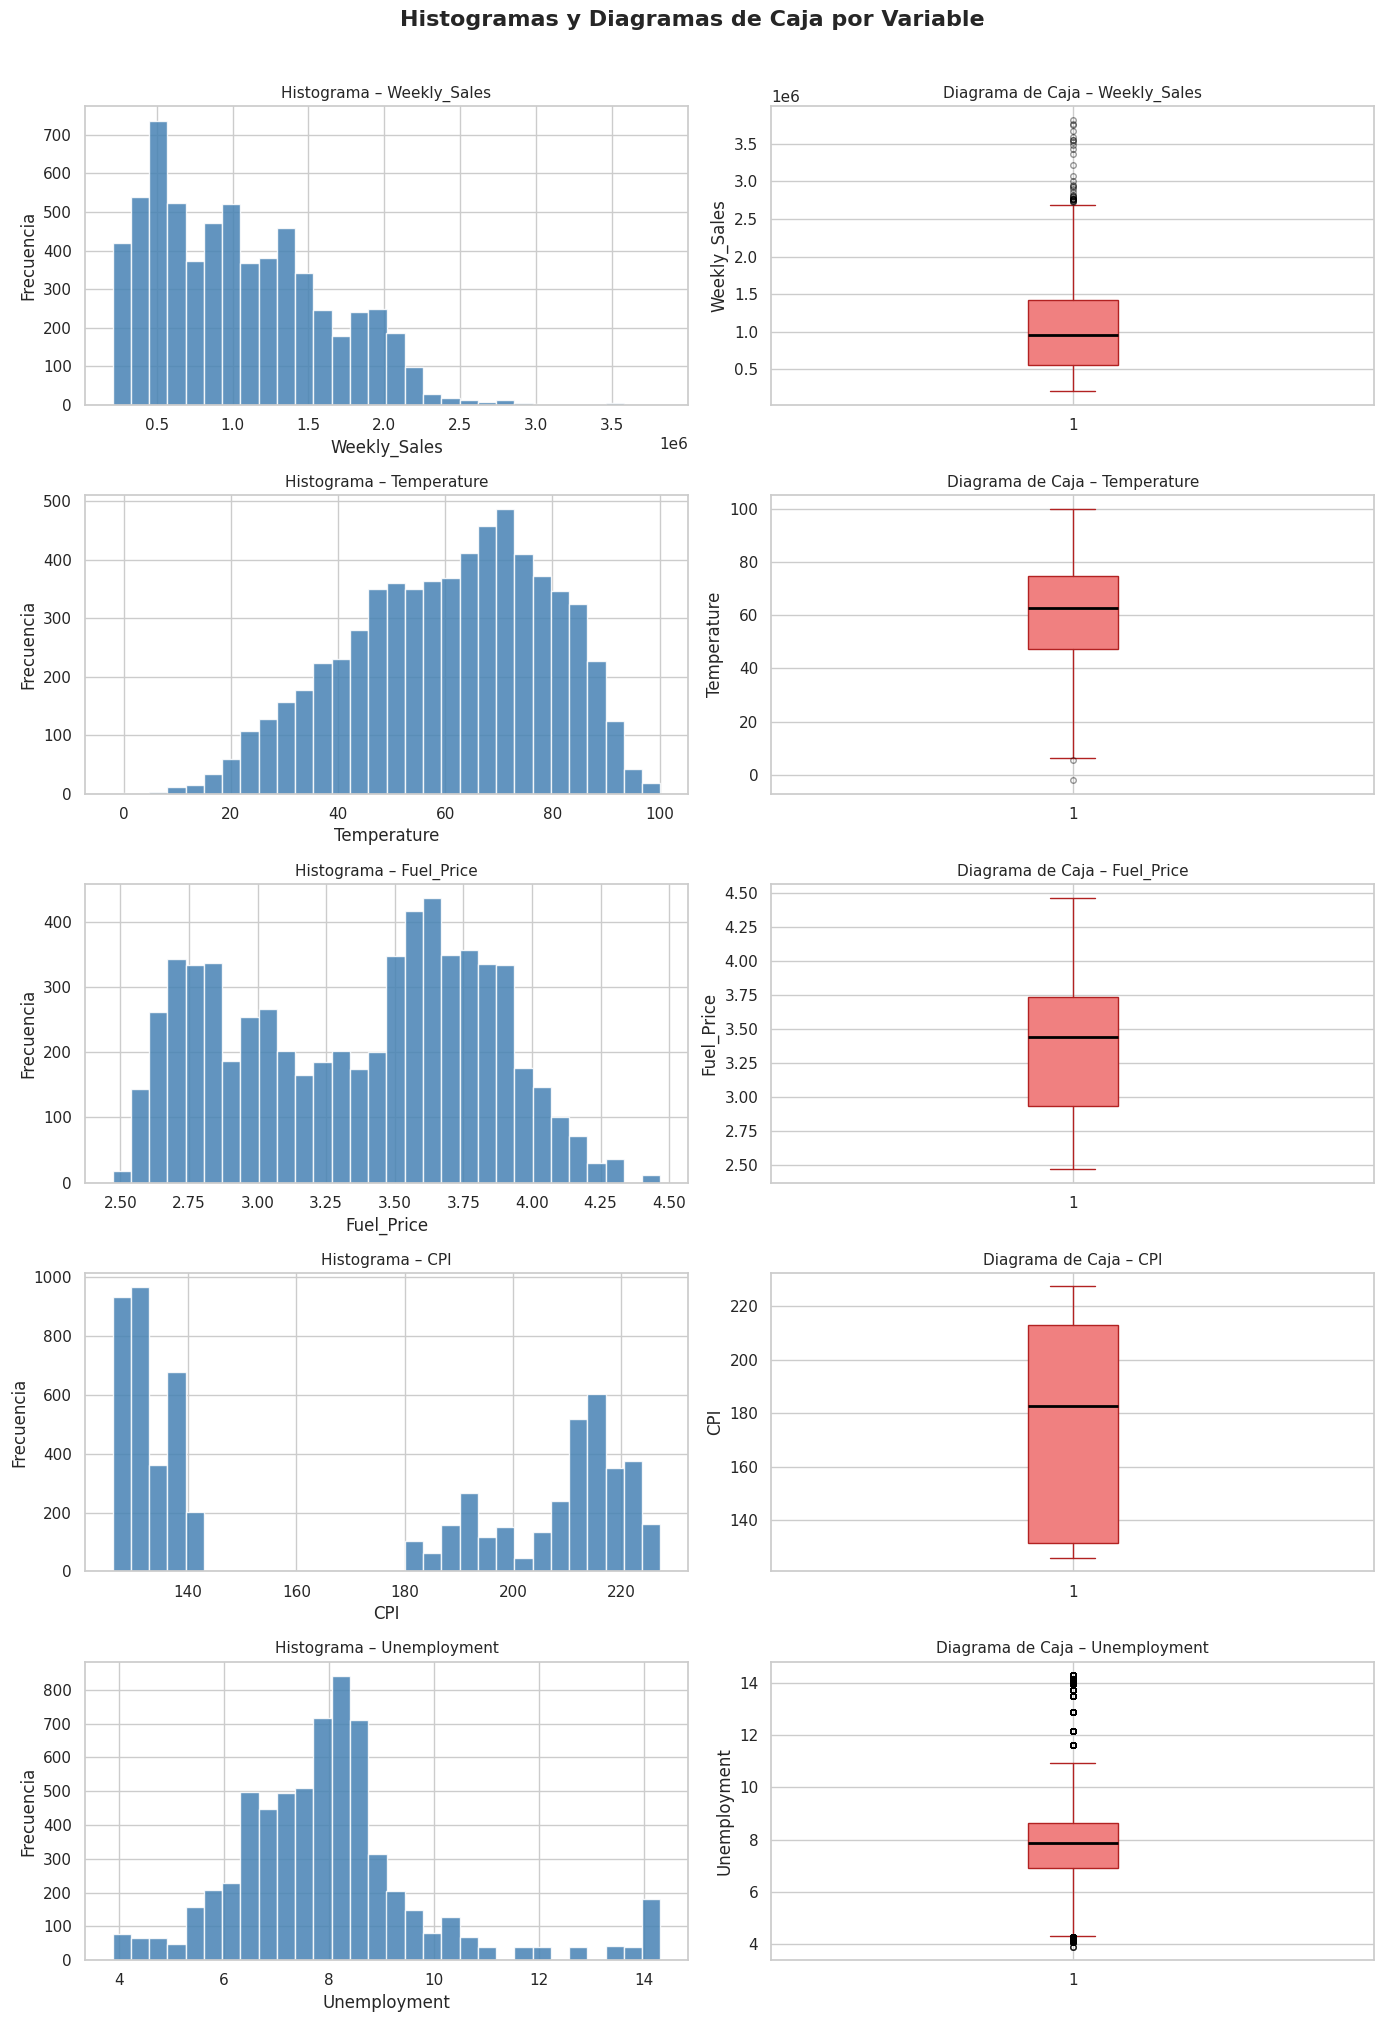

✅ Gráficas generadas.


In [26]:
variables_num = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(nrows=len(variables_num), ncols=2,
                          figsize=(14, 4 * len(variables_num)))
fig.suptitle('Histogramas y Diagramas de Caja por Variable', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(variables_num):
    # Histograma
    axes[i, 0].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'Histograma – {col}', fontsize=11)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frecuencia')

    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', color='firebrick'),
                       medianprops=dict(color='black', linewidth=2),
                       whiskerprops=dict(color='firebrick'),
                       capprops=dict(color='firebrick'),
                       flierprops=dict(marker='o', color='firebrick', alpha=0.4, markersize=4))
    axes[i, 1].set_title(f'Diagrama de Caja – {col}', fontsize=11)
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()
print('✅ Gráficas generadas.')

### 2.7 Corrección / Eliminación de valores atípicos (outliers)

Se usa el método **IQR (Rango Intercuartílico)** para detectar outliers en las variables numéricas.  
Los registros atípicos se guardan en un CSV separado llamado `anomalias.csv`.

In [27]:
def detectar_outliers_iqr(dataframe: pd.DataFrame, columnas: list) -> pd.Series:
    """
    Identifica filas con valores atípicos en al menos una de las columnas
    indicadas, usando el criterio IQR (Q1 - 1.5*IQR  /  Q3 + 1.5*IQR).

    Retorna:
        pd.Series (bool): True donde la fila es atípica.
    """
    mascara = pd.Series(False, index=dataframe.index)
    for col in columnas:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        outliers_col = (dataframe[col] < limite_inf) | (dataframe[col] > limite_sup)
        print(f'  {col:>15}: {outliers_col.sum():>5} outliers  '
              f'(límites: [{limite_inf:.2f}, {limite_sup:.2f}])')
        mascara = mascara | outliers_col
    return mascara


print('Detección de outliers por columna (método IQR):')
print('─' * 60)
mascara_outliers = detectar_outliers_iqr(df, variables_num)

# Separar outliers
df_anomalias = df[mascara_outliers].copy()
df_limpio    = df[~mascara_outliers].copy()
df_limpio.reset_index(drop=True, inplace=True)

print(f'\nTotal de registros atípicos  : {len(df_anomalias)}')
print(f'Total de registros limpios   : {len(df_limpio)}')

# Guardar anomalías
df_anomalias.to_csv('anomalias.csv', index=False)
print('\n✅ Outliers guardados en "anomalias.csv".')
display(df_anomalias.head())

Detección de outliers por columna (método IQR):
────────────────────────────────────────────────────────────
     Weekly_Sales:    34 outliers  (límites: [-746320.94, 2720441.22])
      Temperature:     2 outliers  (límites: [6.15, 116.23])
       Fuel_Price:     0 outliers  (límites: [1.73, 4.94])
              CPI:     0 outliers  (límites: [10.22, 334.26])
     Unemployment:   481 outliers  (límites: [4.29, 11.22])

Total de registros atípicos  : 517
Total de registros limpios   : 5916

✅ Outliers guardados en "anomalias.csv".


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127


In [28]:
# Actualizar df con los datos limpios
df = df_limpio.copy()
print(f'DataFrame de trabajo actualizado → {df.shape[0]} filas × {df.shape[1]} columnas')

DataFrame de trabajo actualizado → 5916 filas × 8 columnas


---
## 3. Selección de Atributos (Feature Selection) *(Opcional)*

### 3.1 Dispersión de cada variable respecto a la variable objetivo (`Weekly_Sales`)

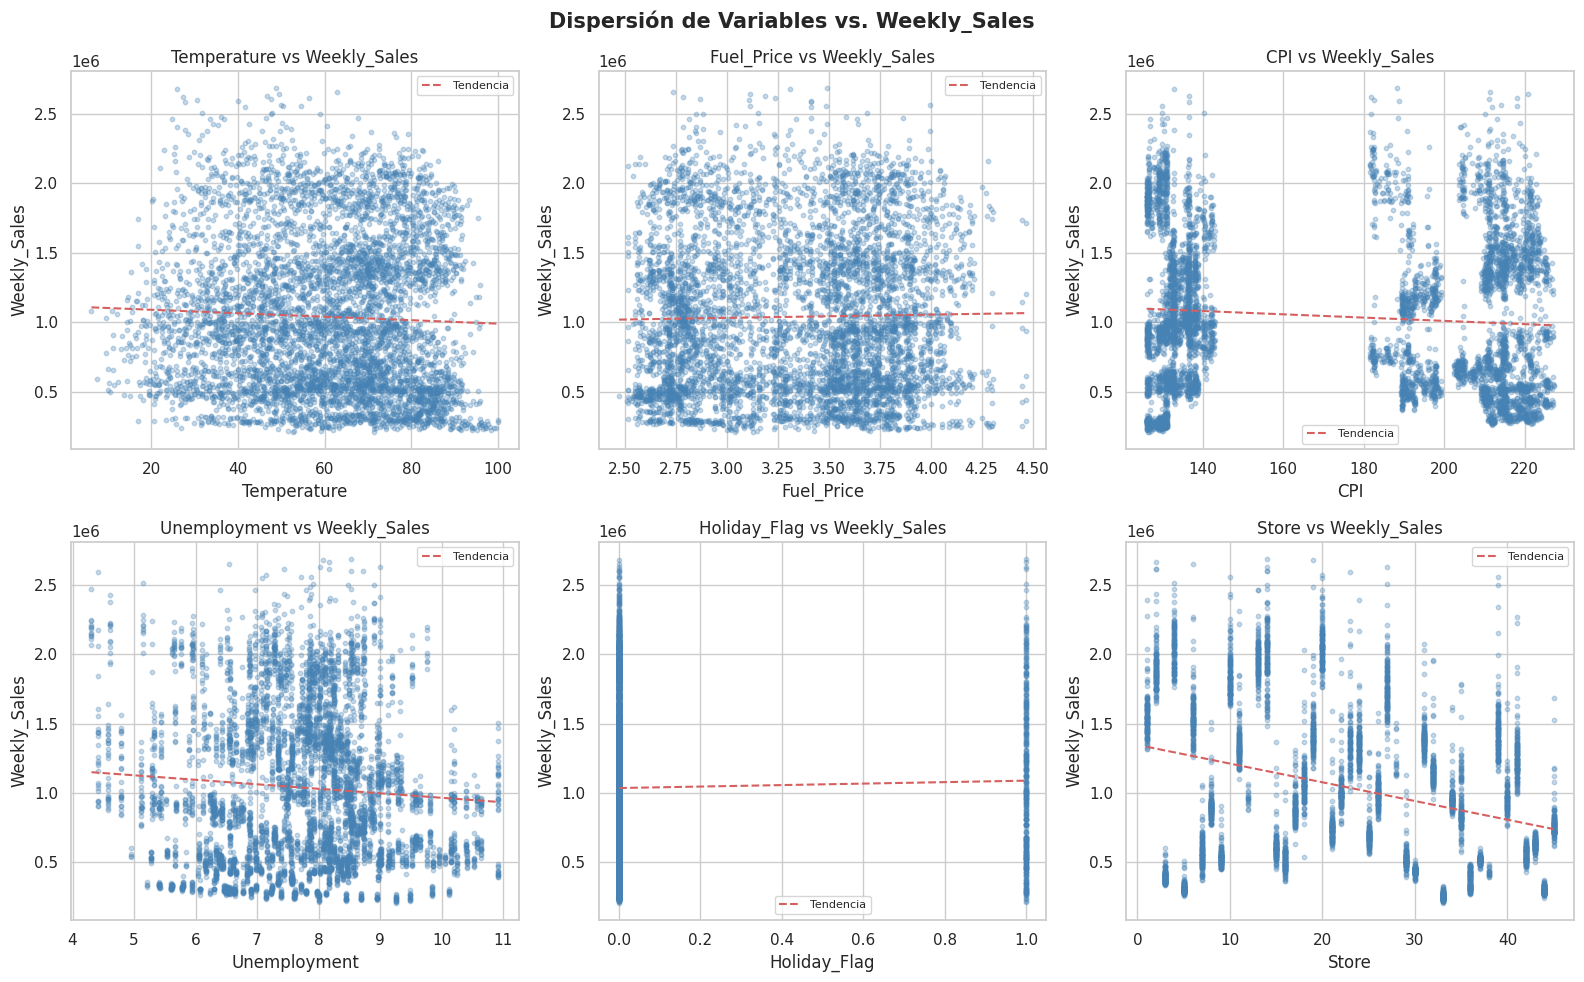

✅ Gráficas de dispersión generadas.


In [29]:
variables_independientes = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag', 'Store']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Dispersión de Variables vs. Weekly_Sales', fontsize=15, fontweight='bold')

for i, col in enumerate(variables_independientes):
    axes[i].scatter(df[col], df['Weekly_Sales'],
                    alpha=0.3, s=10, color='steelblue')
    # Línea de tendencia
    z = np.polyfit(df[col], df['Weekly_Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Tendencia')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Weekly_Sales')
    axes[i].set_title(f'{col} vs Weekly_Sales')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()
print('✅ Gráficas de dispersión generadas.')

### 3.2 Mapa de correlación

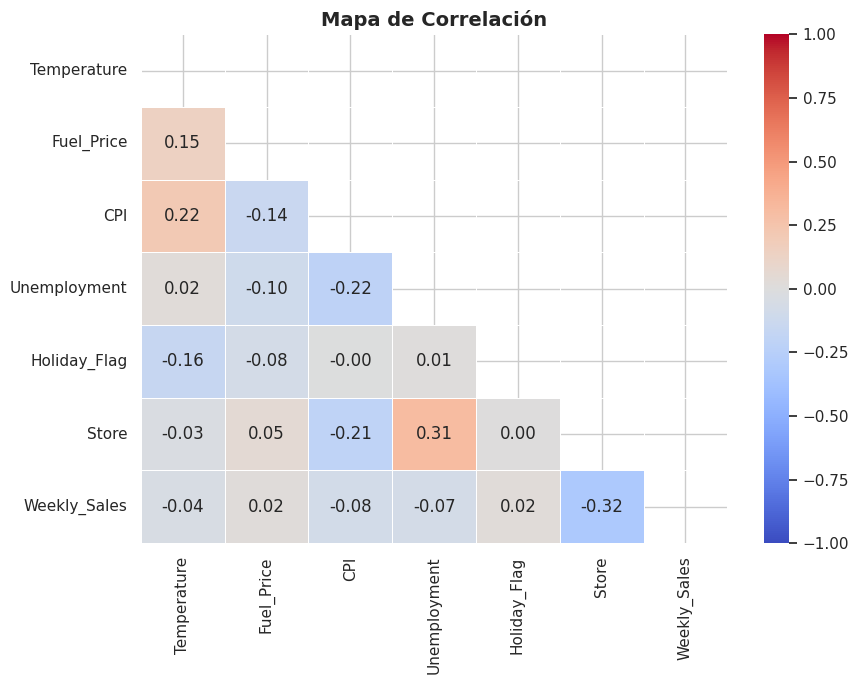


Correlaciones con Weekly_Sales (ordenadas):


Store          -0.319342
CPI            -0.083234
Unemployment   -0.072843
Temperature    -0.041667
Holiday_Flag    0.024361
Fuel_Price      0.019518
Name: Weekly_Sales, dtype: float64

In [30]:
cols_correlacion = variables_independientes + ['Weekly_Sales']
corr_matrix = df[cols_correlacion].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, center=0)
ax.set_title('Mapa de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Weekly_Sales (ordenadas):')
display(corr_matrix['Weekly_Sales'].drop('Weekly_Sales').sort_values(key=abs, ascending=False))

### 3.3 Atributos sin relación con la variable objetivo

Se consideran **sin relación** aquellas variables cuya correlación con `Weekly_Sales` es menor a **0.05** en valor absoluto.  
Se guardan en un CSV separado llamado `atributosSinRelacion.csv`.

In [31]:
UMBRAL_CORRELACION = 0.05

correlaciones = corr_matrix['Weekly_Sales'].drop('Weekly_Sales')
sin_relacion  = correlaciones[abs(correlaciones) < UMBRAL_CORRELACION].index.tolist()
con_relacion  = correlaciones[abs(correlaciones) >= UMBRAL_CORRELACION].index.tolist()

print(f'Umbral de correlación   : |r| < {UMBRAL_CORRELACION}')
print(f'Atributos SIN relación  : {sin_relacion}')
print(f'Atributos CON relación  : {con_relacion}')

if sin_relacion:
    df_sin_relacion = df[sin_relacion].copy()
    df_sin_relacion.to_csv('atributosSinRelacion.csv', index=False)
    print('\n✅ Atributos sin relación guardados en "atributosSinRelacion.csv".')
    display(df_sin_relacion.head())
else:
    print('\nℹ️  Ningún atributo cae por debajo del umbral → no se generó el archivo.')

Umbral de correlación   : |r| < 0.05
Atributos SIN relación  : ['Temperature', 'Fuel_Price', 'Holiday_Flag']
Atributos CON relación  : ['CPI', 'Unemployment', 'Store']

✅ Atributos sin relación guardados en "atributosSinRelacion.csv".


,Temperature,Fuel_Price,Holiday_Flag
0,42.31,2.572,0
1,38.51,2.548,1
2,39.93,2.514,0
3,46.63,2.561,0
4,46.50,2.625,0


### 3.4 DataFrame final con atributos seleccionados

In [32]:
# Columnas a conservar: atributos CON relación + variable objetivo
cols_finales = ['Date'] + con_relacion + ['Weekly_Sales']
df_final = df[cols_finales].copy()

print('═' * 60)
print('DATAFRAME FINAL LISTO PARA MODELADO')
print('═' * 60)
print(f'Dimensiones: {df_final.shape[0]} filas × {df_final.shape[1]} columnas')
print(f'Columnas   : {list(df_final.columns)}')
display(df_final.head())

df_final.to_csv('Walmart_Sales_limpio.csv', index=False)
print('\n✅ 2.')

════════════════════════════════════════════════════════════
DATAFRAME FINAL LISTO PARA MODELADO
════════════════════════════════════════════════════════════
Dimensiones: 5916 filas × 5 columnas
Columnas   : ['Date', 'CPI', 'Unemployment', 'Store', 'Weekly_Sales']


,Date,CPI,Unemployment,Store,Weekly_Sales
0,2010-02-05,211.096358,8.106,1,1643690.90
1,2010-02-12,211.242170,8.106,1,1641957.44
2,2010-02-19,211.289143,8.106,1,1611968.17
3,2010-02-26,211.319643,8.106,1,1409727.59
4,2010-03-05,211.350143,8.106,1,1554806.68



✅ 2.


---
## Resumen del Proceso

| Etapa | Acción | Resultado |
|---|---|---|
| Carga | Lectura del CSV con parseo de fechas | 6 437 registros, 8 columnas |
| Duplicados | `drop_duplicates()` | Registros duplicados eliminados |
| Nulos – `Weekly_Sales` | Relleno con **mediana** | Sin pérdida de registros |
| Nulos – resto | `dropna()` | Filas incompletas eliminadas |
| Outliers | Criterio **IQR** | Separados en `anomalias.csv` |
| Feature Selection | Correlación \|r\| < 0.05 | Descartados en `atributosSinRelacion.csv` |
| Dataset final | Atributos relevantes | `Walmart_Sales_limpio.csv` |